# 2b — The Robot as Code

Which numbers are the body? · SOC4180 Robot and AI

Hong Jeong

<figure>
<a
href="https://colab.research.google.com/github/gnoejh/soc4180/blob/main/weeks/02b-robot-as-code/lab.ipynb"><img
src="https://colab.research.google.com/assets/colab-badge.svg" /></a>
<figcaption>Open In Colab</figcaption>
</figure>

**Before you start, two things:**

1.  **Runtime → Change runtime type → T4 GPU.** Not for training —
    MuJoCo renders the robot through EGL on Colab, and that needs the
    GPU runtime.
2.  **File → Save a copy in Drive.** This notebook is opened from GitHub
    and is *not* saved. Without a copy, your work disappears when you
    close the tab.

## Last class, one leg. This class, the whole robot.

Week 2 answered **“where is the foot?”** from six angles. It never said
*which six numbers* those were, and it never touched the other
twenty-three.

Today the robot stops being a picture and becomes a **data structure you
can read**:

1.  What is the robot, as data? — one tree, five chains.
2.  Which numbers are which body part? — `qpos` is a map.
3.  What does the code in `soc4180/` actually do? — three ideas,
    repeated.

Then, in the lab, you will pose **every** part of the robot by name, and
learn the body by moving it.

------------------------------------------------------------------------

## Setting up

In [1]:
import importlib.util

# On Colab, upgrade unconditionally *before* importing: pip cannot replace a
# module the interpreter has already loaded, and `try: import / except: install`
# never updates a stale copy. Locally there is nothing to install.
if importlib.util.find_spec("google.colab") is not None:
    %pip install -q --upgrade "soc4180 @ git+https://github.com/gnoejh/soc4180.git"

import numpy as np
import matplotlib.pyplot as plt
import soc4180          # first: it selects the GL backend before mujoco loads
import mujoco
from soc4180 import bodies as B

model = soc4180.load_g1()
data = soc4180.keyframe_data(model, "stand")
mujoco.mj_forward(model, data)

print(f"nbody {model.nbody}   njnt {model.njnt}   nsite {model.nsite}")
print(f"nq    {model.nq}   nv   {model.nv}   nu    {model.nu}")

nbody 31   njnt 30   nsite 4
nq    36   nv   35   nu    29

Six numbers describe the entire robot’s *shape as data*:

- **`nbody` 31** rigid links, one of them the `world`
- **`njnt` 30** joints — 1 floating base + **29 hinges**
- **`nq` 36 / `nv` 35** — the state, in position and in velocity space
- **`nu` 29** actuators, one per hinge
- **`nsite` 4** — two feet and two IMUs, and *nothing else*

------------------------------------------------------------------------

## The robot is a tree

Every body has exactly **one parent**. That is not a convention, it is
the definition: `model.body_parentid` is the whole skeleton.

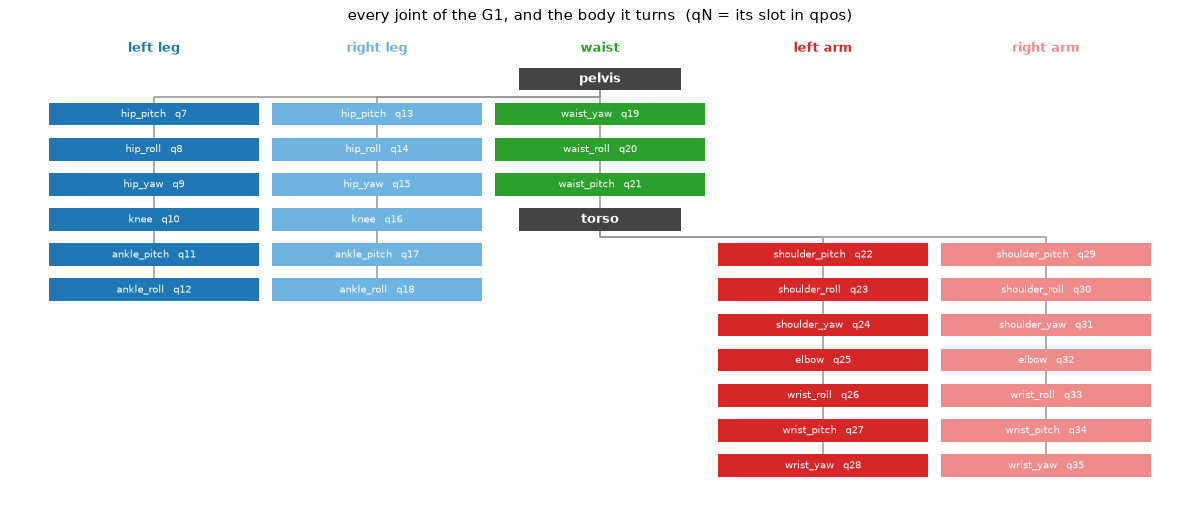

In [2]:
COLOUR = {"left_leg": "#1f77b4", "right_leg": "#6fb3e0", "waist": "#2ca02c",
          "left_arm": "#d62728", "right_arm": "#f08b8c"}
COL_X = {"left_leg": -3.4, "right_leg": -1.7, "waist": 0.0,
         "left_arm": 1.7, "right_arm": 3.4}
ROW = 0.62
TORSO_Y = -4 * ROW                        # waist has 3 joints, then the torso

def _body_of(joint):
    jid = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_JOINT, joint)
    return int(model.jnt_bodyid[jid])

def _box(ax, x, y, text, colour, w=0.80, bold=False):
    ax.add_patch(plt.Rectangle((x - w, y - 0.20), 2 * w, 0.40, fc=colour,
                               ec="none", zorder=3))
    ax.text(x, y, text, color="w", ha="center", va="center", zorder=4,
            fontsize=9.5 if bold else 7.5, fontweight="bold" if bold else "normal")

fig, ax = plt.subplots(figsize=(12.6, 5.4))
node = {}
_box(ax, 0, 0, "pelvis", "#444", w=0.62, bold=True)
_box(ax, 0, TORSO_Y, "torso", "#444", w=0.62, bold=True)

for chain, joints in B.CHAINS.items():
    x = COL_X[chain]
    start = 5 if "arm" in chain else 1     # arms hang below the torso
    for depth, jname in enumerate(joints):
        y = -(start + depth) * ROW
        node[jname] = (x, y)
        short = jname.replace("_joint", "").replace("left_", "").replace("right_", "")
        _box(ax, x, y, f"{short}   q{B.joint_index(model, jname)}", COLOUR[chain])

def _elbow(a, b):                          # a right-angled connector, parent -> child
    mid = (a[1] + b[1]) / 2
    ax.plot([a[0], a[0], b[0], b[0]], [a[1], mid, mid, b[1]], color="#999", lw=1.2, zorder=1)

for chain, joints in B.CHAINS.items():
    _elbow((0, TORSO_Y) if "arm" in chain else (0, 0), node[joints[0]])
    for parent, child in zip(joints, joints[1:]):
        _elbow(node[parent], node[child])
_elbow(node["waist_pitch_joint"], (0, TORSO_Y))

for chain, x in COL_X.items():
    ax.text(x, 0.48, chain.replace("_", " "), ha="center", fontsize=10,
            color=COLOUR[chain], fontweight="bold")
ax.set_xlim(-4.5, 4.5); ax.set_ylim(-7.4, 0.9); ax.axis("off")
ax.set_title("every joint of the G1, and the body it turns  "
             "(qN = its slot in qpos)", fontsize=11)
fig.tight_layout(); plt.show()

------------------------------------------------------------------------

## Five chains, one pelvis

Read the tree again and the robot’s whole layout falls out of it:

In [3]:
print(B.describe(model))
print()
print("joints in the chains:", sum(len(j) for j in B.CHAINS.values()), " nu:", model.nu)

chain      joints   qpos slots   qvel slots
left_leg        6     7..12        6..11  
right_leg       6    13..18       12..17  
waist           3    19..21       18..20  
left_arm        7    22..28       21..27  
right_arm       7    29..35       28..34  

joints in the chains: 29  nu: 29

$6 + 6 + 3 + 7 + 7 = 29$, and that is **exactly `nu`**. There is nothing
else — no head joint, no hands, no neck. The “head” you see in the
render is welded to the torso.

Three facts you will use all term:

- The legs hang off the **pelvis**; the arms hang off the **torso**,
  which is three waist joints further up. So the waist moves both arms
  and neither leg.
- Every chain’s joints are **contiguous in `qpos`**, in root-to-tip
  order.
- A chain is a **path in the tree**. `kinematics.LEG_CHAIN` from week 2
  is exactly the left-hand column of that diagram.

------------------------------------------------------------------------

## `qpos` is a map of the body

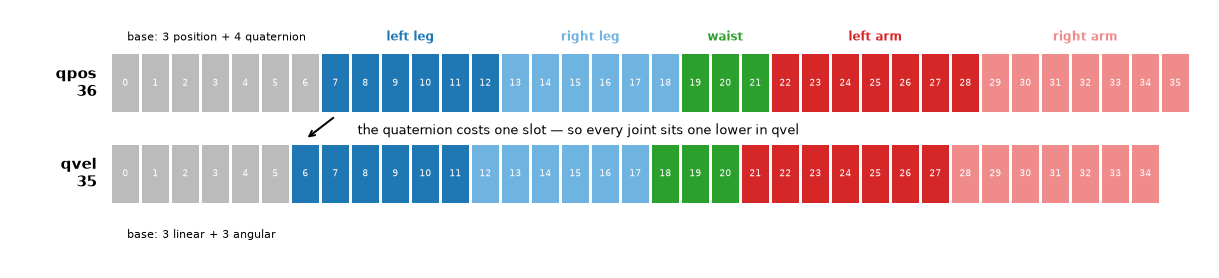

In [4]:
slot_chain = {}
for chain in B.CHAINS:
    for q, v in zip(B.group_indices(model, chain), B.group_indices(model, chain, dof=True)):
        slot_chain[("q", int(q))] = chain
        slot_chain[("v", int(v))] = chain

fig, ax = plt.subplots(figsize=(12.8, 3.0))
for row, (tag, n, y) in enumerate((("q", model.nq, 1.15), ("v", model.nv, 0.05))):
    for i in range(n):
        colour = COLOUR.get(slot_chain.get((tag, i)), "#bbbbbb")
        ax.add_patch(plt.Rectangle((i, y), 0.92, 0.7, fc=colour, ec="none"))
        ax.text(i + 0.46, y + 0.35, str(i), ha="center", va="center",
                fontsize=6.5, color="w")

ax.text(-0.5, 1.50, f"qpos\n{model.nq}", ha="right", va="center", fontsize=11, fontweight="bold")
ax.text(-0.5, 0.40, f"qvel\n{model.nv}", ha="right", va="center", fontsize=11, fontweight="bold")
ax.text(3.5, 2.02, "base: 3 position + 4 quaternion", ha="center", fontsize=8.5)
ax.text(3.0, -0.38, "base: 3 linear + 3 angular", ha="center", fontsize=8.5)
for chain in B.CHAINS:
    q = B.group_indices(model, chain)
    ax.text(q.mean() + 0.46, 2.02, chain.replace("_", " "), ha="center",
            fontsize=9, color=COLOUR[chain], fontweight="bold")
ax.annotate("", xy=(6.46, 0.82), xytext=(7.46, 1.10),
            arrowprops=dict(arrowstyle="->", color="k", lw=1.5))
ax.text(8.2, 0.88, "the quaternion costs one slot — so every joint sits "
                   "one lower in qvel", fontsize=9.5)
ax.set_xlim(-3.4, 36.6); ax.set_ylim(-0.75, 2.4); ax.axis("off")
fig.tight_layout(); plt.show()

The body part **is** a slice. `data.qpos[22:29]` is the left arm, and it
is the left arm on every G1 in the world, because the MJCF says so.

------------------------------------------------------------------------

## The off-by-one that never raises

Week 2 met this as `leg_qpos_indices` returning `7..12` while
`leg_dof_indices` returns `6..11`. Now you can see why, and that it is
true of the **whole** robot:

In [5]:
for name in ("left_hip_pitch", "waist_yaw", "left_elbow", "right_wrist_yaw"):
    print(f"{name:18s} qpos {B.joint_index(model, name):2d}   "
          f"qvel {B.dof_index(model, name):2d}")

offsets = {B.joint_index(model, j) - B.dof_index(model, j)
           for chain in B.CHAINS for j in B.CHAINS[chain]}
print("\nqpos index minus qvel index, over all 29 joints:", offsets)

left_hip_pitch     qpos  7   qvel  6
waist_yaw          qpos 19   qvel 18
left_elbow         qpos 25   qvel 24
right_wrist_yaw    qpos 35   qvel 34

qpos index minus qvel index, over all 29 joints: {1}

**Always one.** The floating base spends 7 numbers on position and 6 on
velocity, because you cannot store a 3-D rotation in 3 numbers without a
singularity (week 2’s gimbal lock), but its *rate* is an honest
3-vector.

The danger is that both indices are valid. Use a `qvel` index on `qpos`
and you silently read the **neighbouring joint** — an elbow where you
meant a shoulder. Nothing raises. Nothing warns. The robot simply does
the wrong thing.

------------------------------------------------------------------------

## Name the joint; do not count the slots

Counting slots by hand is how that bug gets written. So `soc4180.bodies`
does the counting, and you write names:

In [6]:
soc4180.set_pose(model, data, left_elbow=1.2, waist_yaw=-0.4)
print("left elbow now:", data.qpos[B.joint_index(model, "left_elbow")])

soc4180.set_pose(model, data, left_arm=[0, 0.3, 0, 1.2, 0, 0, 0])   # a whole chain
print("left arm now:  ", data.qpos[B.group_indices(model, "left_arm")].round(2))

soc4180.set_pose(model, data, left_knee=40, right_knee=40, degrees=True)
print("both knees:    ", data.qpos[[B.joint_index(model, "left_knee"),
                                    B.joint_index(model, "right_knee")]].round(3), "rad")

left elbow now: 1.2
left arm now:   [0.  0.3 0.  1.2 0.  0.  0. ]
both knees:     [0.698 0.698] rad

Three things `set_pose` does, and each one is a decision you would
otherwise make every time:

- `left_elbow` → `left_elbow_joint` → joint id → `jnt_qposadr` → slot
  25.
- **Resets to the `stand` keyframe first**, so a pose is a complete
  description and not a mystery accumulated from earlier cells. Pass
  `reset=None` to layer.
- Calls `mj_forward`, so the answer is ready the instant the call
  returns.

------------------------------------------------------------------------

## What `mj_forward` actually does

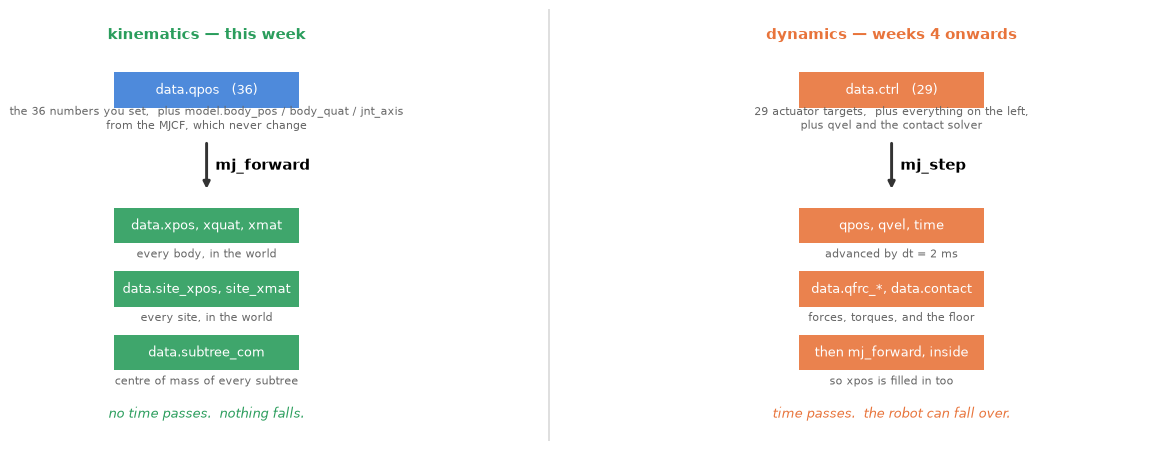

In [7]:
fig, ax = plt.subplots(figsize=(12.4, 4.8))

def box(x, y, label, colour, note=""):
    ax.add_patch(plt.Rectangle((x - 1.7, y - 0.21), 3.4, 0.42, fc=colour,
                               ec="none", alpha=0.9))
    ax.text(x, y, label, ha="center", va="center", color="w", fontsize=9.5)
    if note:
        ax.text(x, y - 0.34, note, ha="center", va="center", fontsize=8, color="#666")

def column(x, title, colour, source, call, results, footer):
    ax.text(x, 4.75, title, ha="center", fontsize=11.5, fontweight="bold", color=colour)
    box(x, 4.15, *source)
    ax.annotate("", xy=(x, 2.95), xytext=(x, 3.55),
                arrowprops=dict(arrowstyle="-|>", color="#333", lw=2.2))
    ax.text(x + 0.16, 3.25, call, fontsize=11, fontweight="bold", va="center")
    for k, (label, note) in enumerate(results):
        box(x, 2.55 - k * 0.75, label, colour, note)
    ax.text(x, 0.28, footer, ha="center", fontsize=10, style="italic", color=colour)

column(0, "kinematics — this week", "#2a9d5c",
       ("data.qpos   (36)", "#3b7dd8",
        "the 36 numbers you set,  plus model.body_pos / body_quat / jnt_axis"
        "\nfrom the MJCF, which never change"),
       "mj_forward",
       [("data.xpos, xquat, xmat", "every body, in the world"),
        ("data.site_xpos, site_xmat", "every site, in the world"),
        ("data.subtree_com", "centre of mass of every subtree")],
       "no time passes.  nothing falls.")

ax.axvline(6.3, color="#ddd", lw=1.4)

column(12.6, "dynamics — weeks 4 onwards", "#e8743b",
       ("data.ctrl   (29)", "#e8743b",
        "29 actuator targets,  plus everything on the left,"
        "\nplus qvel and the contact solver"),
       "mj_step",
       [("qpos, qvel, time", "advanced by dt = 2 ms"),
        ("data.qfrc_*, data.contact", "forces, torques, and the floor"),
        ("then mj_forward, inside", "so xpos is filled in too")],
       "time passes.  the robot can fall over.")

ax.set_xlim(-2.4, 17.4); ax.set_ylim(0.0, 5.1); ax.axis("off")
fig.tight_layout(); plt.show()

Everything this week is the **left** path. `ctrl` appears nowhere —
which is exactly why the viewer’s Control sliders look broken in a
kinematic script until you wire them onto `qpos` yourself.

------------------------------------------------------------------------

## Four poses, four lines

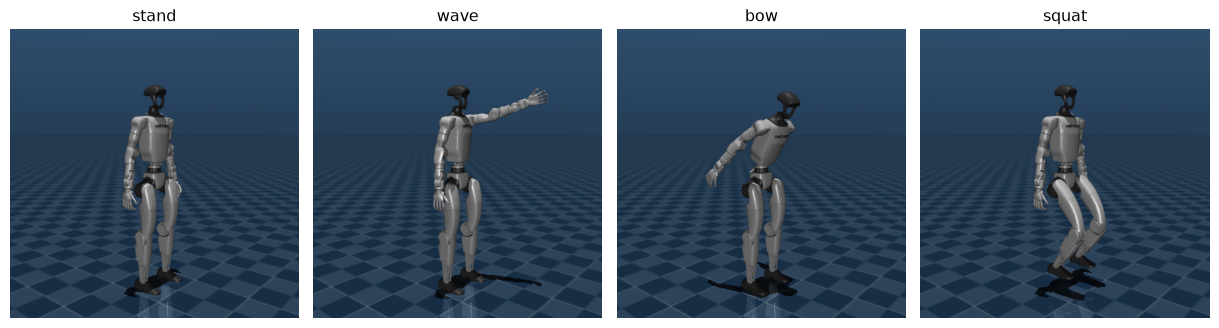

In [8]:
POSES = {
    "stand": {},
    "wave": dict(left_shoulder_pitch=-1.7, left_shoulder_roll=0.5,
                 left_elbow=1.4, waist_yaw=0.25),
    "bow": dict(waist_pitch=0.5, left_shoulder_pitch=0.5, right_shoulder_pitch=0.5),
    "squat": dict(left_leg=[-0.6, 0, 0, 1.2, -0.6, 0],
                  right_leg=[-0.6, 0, 0, 1.2, -0.6, 0]),
}

camera = mujoco.MjvCamera()
camera.type = mujoco.mjtCamera.mjCAMERA_FREE
camera.distance, camera.azimuth, camera.elevation = 2.3, 130, -8
camera.lookat[:] = [0, 0, 0.75]

qposes = []
for angles in POSES.values():
    soc4180.set_pose(model, data, **angles)
    qposes.append(data.qpos.copy())

frames = soc4180.render_poses(model, qposes, width=480, height=480, camera=camera)

fig, axes = plt.subplots(1, 4, figsize=(12.8, 3.6))
for ax, frame, name in zip(axes, frames, POSES):
    ax.imshow(frame); ax.set_title(name, fontsize=12); ax.axis("off")
fig.tight_layout(); plt.show()

Read the `squat` entry again: **a chain takes one number per joint, root
to tip** — hip pitch, hip roll, hip yaw, knee, ankle pitch, ankle roll.
The pitch angles sum to zero, which is what keeps the foot level.

------------------------------------------------------------------------

## …and the squat is floating

Look at the fourth frame: the shadow is on the floor and the feet are
not.

In [9]:
foot = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_SITE, "left_foot")
soc4180.set_pose(model, data)
on_floor = data.site_xpos[foot][2]
soc4180.set_pose(model, data, left_leg=[-0.6, 0, 0, 1.2, -0.6, 0],
                 right_leg=[-0.6, 0, 0, 1.2, -0.6, 0])
lifted = data.site_xpos[foot][2]

print(f"foot site standing : {on_floor:.4f} m")
print(f"foot site squatting: {lifted:.4f} m")
print(f"lifted by          : {lifted - on_floor:.4f} m")
print(f"pelvis height      : {data.qpos[2]:.4f} m   (unchanged — you never moved it)")

foot site standing : 0.0331 m
foot site squatting: 0.1443 m
lifted by          : 0.1112 m
pelvis height      : 0.7900 m   (unchanged — you never moved it)

This is week 2’s warning again, now for the whole body: **`set_pose`
places a pose; it does not settle a robot.** Bending the knees with the
pelvis pinned shortens the legs and lifts the feet. A real squat lowers
the pelvis by the same amount — which is exactly what week 4’s walking
controller spends its time deciding, and week 3’s IK is how it gets
there.

------------------------------------------------------------------------

## Every joint, and what it moves

Turn one joint by $0.1$ rad ($5.7°$) from `stand` and measure how far
five landmarks travel. This is week 2’s Jacobian bar chart, for the
entire robot:

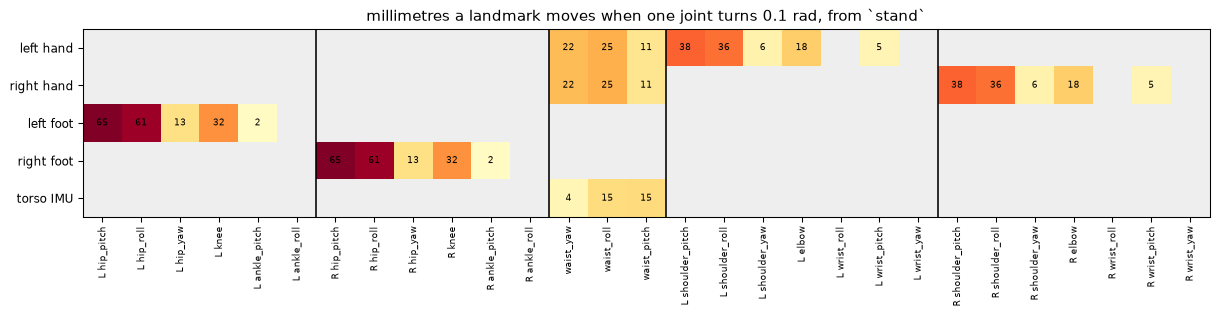

In [10]:
LANDMARKS = [("left hand", "left_wrist_yaw_link"), ("right hand", "right_wrist_yaw_link"),
             ("left foot", "left_ankle_roll_link"), ("right foot", "right_ankle_roll_link")]
bodies = [mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_BODY, b) for _, b in LANDMARKS]
imu = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_SITE, "imu_in_torso")

def probe():
    return np.array([*(data.xpos[b] for b in bodies), data.site_xpos[imu]])

soc4180.set_pose(model, data); rest = probe()
joints = [j for chain in B.CHAINS for j in B.CHAINS[chain]]
effect = np.zeros((5, len(joints)))
for k, jname in enumerate(joints):
    soc4180.set_pose(model, data)
    soc4180.set_pose(model, data, reset=None,
                     **{jname: data.qpos[B.joint_index(model, jname)] + 0.1})
    effect[:, k] = 1000 * np.linalg.norm(probe() - rest, axis=1)

fig, ax = plt.subplots(figsize=(12.8, 3.4))
ax.set_facecolor("#eeeeee")
ZERO = 1e-9                     # mm; below this is float noise, not motion
shown = np.where(effect > ZERO, effect, np.nan)
ax.imshow(shown, aspect="auto", cmap="YlOrRd", vmin=0, vmax=effect.max())
for i in range(effect.shape[0]):
    for k in range(effect.shape[1]):
        if effect[i, k] > ZERO:
            ax.text(k, i, f"{effect[i, k]:.0f}", ha="center", va="center", fontsize=6.5)
ax.set_yticks(range(5))
ax.set_yticklabels([n for n, _ in LANDMARKS] + ["torso IMU"], fontsize=9)
ax.set_xticks(range(len(joints)))
ax.set_xticklabels([j.replace("_joint", "").replace("left_", "L ").replace("right_", "R ")
                    for j in joints], rotation=90, fontsize=6.5)
edge = 0
for chain in B.CHAINS:
    edge += len(B.CHAINS[chain])
    if edge < len(joints):
        ax.axvline(edge - 0.5, color="k", lw=1.2)
ax.set_title("millimetres a landmark moves when one joint turns 0.1 rad, from `stand`",
             fontsize=11)
fig.tight_layout(); plt.show()

------------------------------------------------------------------------

## The grey is the tree

The blank cells are not small numbers. They are **zero to the last bit
of a double** — the largest of them is $7 \times 10^{-15}$ mm, which is
float arithmetic, not movement. Their pattern is the tree diagram from
the start of the deck, redrawn in numbers:

- A **leg** joint moves one foot and *nothing else* — not the other
  foot, not a hand, not the torso. The legs are separate branches.
- A **waist** joint moves **both hands and neither foot**. Everything
  above the waist is downstream of it; everything below is not.
- An **arm** joint moves one hand and stops there. Arms are leaves.
- Left and right agree to the millimetre: hip pitch $65$ and $65$,
  shoulder pitch $38$ and $38$.

And the *sizes* are the lever arms. Within a limb the effect falls off
from root to tip — hip pitch $65$, knee $32$, ankle pitch $2$ — because
a joint carries everything below it. **The root of a chain is always the
loud one.** That is why week 4’s walking controller spends its effort on
hips and knees, and why an ankle is for trimming.

------------------------------------------------------------------------

## Three joints that move nothing at all

In [11]:
for jname, landmark in (("left_ankle_roll", "left_ankle_roll_link"),
                        ("left_wrist_roll", "left_wrist_yaw_link"),
                        ("left_wrist_yaw", "left_wrist_yaw_link")):
    bid = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_BODY, landmark)
    soc4180.set_pose(model, data)
    before, before_R = data.xpos[bid].copy(), data.xmat[bid].reshape(3, 3).copy()
    soc4180.set_pose(model, data, reset=None,
                     **{jname: data.qpos[B.joint_index(model, jname)] + 0.5})
    moved = 1000 * np.linalg.norm(data.xpos[bid] - before)
    turn = data.xmat[bid].reshape(3, 3) @ before_R.T        # the rotation it *did* cause
    rotated = np.degrees(np.arccos(np.clip((np.trace(turn) - 1) / 2, -1, 1)))
    print(f"{jname:18s} +0.5 rad -> moves {moved:8.5f} mm,  rotates {rotated:5.1f} deg")

left_ankle_roll    +0.5 rad -> moves  0.00000 mm,  rotates  28.6 deg
left_wrist_roll    +0.5 rad -> moves  0.00000 mm,  rotates  28.6 deg
left_wrist_yaw     +0.5 rad -> moves  0.00000 mm,  rotates  28.6 deg

Zero to every decimal place, because **the landmark sits on the joint’s
own axis** — spinning a point about a line through itself does not move
it. Week 2 found this once, as the `ankle_roll` column of zeros in the
position Jacobian. It is a property of where the MJCF author put the
body origin, not of the robot.

The joints are not useless: they *rotate*. Position is only half of a
pose, and next week’s IK solves both.

------------------------------------------------------------------------

## Left and right, and the 10 micrometres

Mirroring a humanoid negates $y$. Rotations about $x$ (**roll**) and $z$
(**yaw**) reverse; rotations about $y$ (**pitch**) do not. The MJCF’s
own `stand` keyframe says so:

In [12]:
soc4180.set_pose(model, data)
print("stand, left arm :", data.qpos[B.group_indices(model, "left_arm")].round(2))
print("stand, right arm:", data.qpos[B.group_indices(model, "right_arm")].round(2))

pose = dict(left_shoulder_pitch=-0.6, left_shoulder_roll=0.9, left_elbow=1.1)
print("\nmirror(pose) =", {k: round(v, 2) for k, v in soc4180.mirror(pose).items()})

hand = {s: mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_BODY, f"{s}_wrist_yaw_link")
        for s in ("left", "right")}
soc4180.set_pose(model, data, **pose);                 lh = data.xpos[hand["left"]].copy()
soc4180.set_pose(model, data, **soc4180.mirror(pose)); rh = data.xpos[hand["right"]].copy()
print(f"\nleft hand  {lh.round(6)}")
print(f"right hand {rh.round(6)}")
print(f"disagreement after negating y: {np.abs(lh * [1, -1, 1] - rh).max() * 1e6:.1f} micrometres")

stand, left arm : [0.2  0.2  0.   1.28 0.   0.   0.  ]
stand, right arm: [ 0.2  -0.2   0.    1.28  0.    0.    0.  ]

mirror(pose) = {'right_shoulder_pitch': -0.6, 'right_shoulder_roll': -0.9, 'right_elbow': 1.1}

left hand  [0.241521 0.393198 0.965041]
right hand [ 0.241521 -0.393188  0.965041]
disagreement after negating y: 10.0 micrometres

Not $10^{-16}$ — **10 µm**. The robot is not perfectly symmetric, and
the residual is one number in the MJCF: the left shoulder sits at
$y = +0.100220$ and the right at $y = -0.100210$. A CAD rounding
artefact, one part in ten thousand, and now you know it is in the model
and not in your code.

------------------------------------------------------------------------

## The package, in one picture

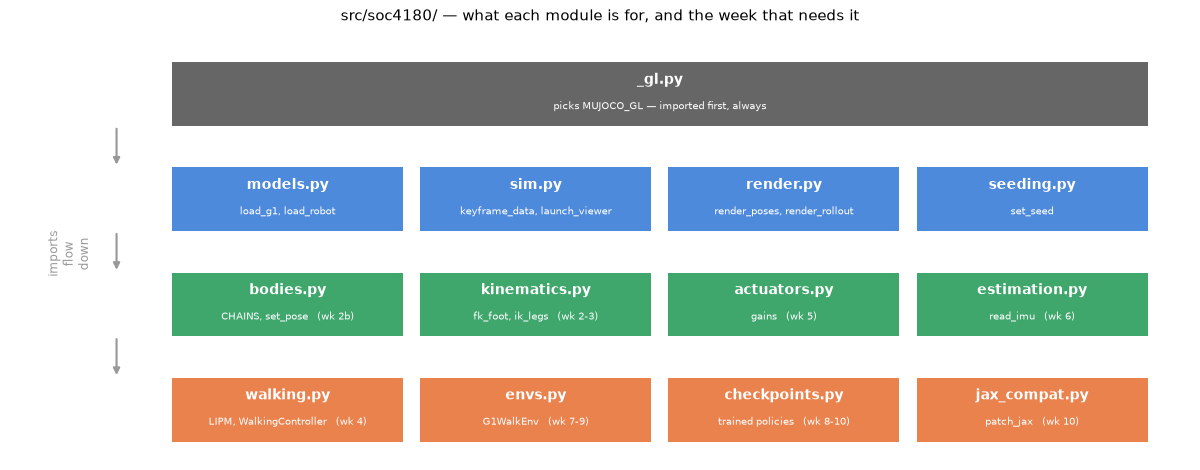

In [13]:
LAYERS = [
    [("_gl.py", "picks MUJOCO_GL — imported first, always", "#555")],
    [("models.py", "load_g1, load_robot", "#3b7dd8"),
     ("sim.py", "keyframe_data, launch_viewer", "#3b7dd8"),
     ("render.py", "render_poses, render_rollout", "#3b7dd8"),
     ("seeding.py", "set_seed", "#3b7dd8")],
    [("bodies.py", "CHAINS, set_pose   (wk 2b)", "#2a9d5c"),
     ("kinematics.py", "fk_foot, ik_legs   (wk 2-3)", "#2a9d5c"),
     ("actuators.py", "gains   (wk 5)", "#2a9d5c"),
     ("estimation.py", "read_imu   (wk 6)", "#2a9d5c")],
    [("walking.py", "LIPM, WalkingController   (wk 4)", "#e8743b"),
     ("envs.py", "G1WalkEnv   (wk 7-9)", "#e8743b"),
     ("checkpoints.py", "trained policies   (wk 8-10)", "#e8743b"),
     ("jax_compat.py", "patch_jax   (wk 10)", "#e8743b")],
]

fig, ax = plt.subplots(figsize=(12.6, 5.0))
for row, layer in enumerate(LAYERS):
    y = -row * 1.12
    width = 11.6 / len(layer)
    for col, (name, note, colour) in enumerate(layer):
        x = -5.8 + col * width + width / 2
        ax.add_patch(plt.Rectangle((x - width / 2 + 0.10, y - 0.34),
                                   width - 0.20, 0.68, fc=colour, ec="none", alpha=0.9))
        ax.text(x, y + 0.11, name, ha="center", color="w", fontsize=10.5, fontweight="bold")
        ax.text(x, y - 0.16, note, ha="center", color="w", fontsize=7.5)
    if row:
        ax.annotate("", xy=(-6.35, y + 0.34), xytext=(-6.35, y + 0.78),
                    arrowprops=dict(arrowstyle="-|>", color="#999", lw=1.6))
ax.text(-6.9, -1.7, "imports\nflow\ndown", ha="center", va="center",
        fontsize=9, color="#999", rotation=90)
ax.set_xlim(-7.6, 6.2); ax.set_ylim(-3.9, 0.7); ax.axis("off")
ax.set_title("src/soc4180/ — what each module is for, and the week that needs it",
             fontsize=11)
fig.tight_layout(); plt.show()

The arrow direction is a rule, not a drawing: **`_gl` must be imported
before anything that imports `mujoco`**, because MuJoCo reads
`MUJOCO_GL` once, at import. Get that order wrong and rendering works on
Windows and dies on Colab.

------------------------------------------------------------------------

## `bodies.py` is three ideas

Open it. Four hundred words of docstring around three things you have
already seen:

In [14]:
# 1. a name -> id lookup, because ids move when the MJCF changes and names do not
jid = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_JOINT, "left_elbow_joint")

# 2. an id -> slot translation, which is the whole off-by-one problem
slot = model.jnt_qposadr[jid]        # position space
col = model.jnt_dofadr[jid]          # velocity space

# 3. write, then mj_forward
data.qpos[slot] = 1.2
mujoco.mj_forward(model, data)

hand = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_BODY, "left_wrist_yaw_link")
print(f"joint id {jid}   qpos slot {slot}   qvel column {col}")
print(f"left hand now at {data.xpos[hand].round(4)}")
print("soc4180.set_pose does exactly this, from the name alone")

joint id 19   qpos slot 25   qvel column 24
left hand now at [-0.0023  0.2218  0.7221]
soc4180.set_pose does exactly this, from the name alone

`CHAINS` is a hand-written table, and it is hand-written **on purpose**:
the grouping into “left arm” and “waist” is anatomy, and the model does
not record it. MuJoCo knows `left_elbow_joint`’s parent is
`left_shoulder_yaw_link`; it has no idea that humans call the assembly
an arm.

**Everything else in the file is error messages.** Read `_full_name` and
count how many lines exist only so that a typo says *“no joint named
‘left_ellbow’”* instead of failing somewhere else entirely.

------------------------------------------------------------------------

## `kinematics.fk_foot` walks that diagram

Week 2’s twelve lines, read against the tree:

``` python
pos = qpos[:3].copy()                       # start at the pelvis
rot = quat2mat(qpos[3:7])                   #   (the floating base, slots 0..6)

for bid in leg_chain(model, side):          # one column of the tree diagram
    pos = pos + rot @ model.body_pos[bid]   # the fixed offset from the parent
    rot = rot @ quat2mat(model.body_quat[bid])
    jnt = model.body_jntadr[bid]
    if jnt >= 0:
        rot_j = axis_angle(model.jnt_axis[jnt], qpos[model.jnt_qposadr[jnt]])
        pos = pos + rot @ (anchor - rot_j @ anchor)
        rot = rot @ rot_j                   # then the joint's own rotation
```

Three observations that make it readable:

- `leg_chain` returns **body ids down one branch** — the loop is a walk
  from the pelvis to the foot, one box per iteration.
- `model.body_pos` has **no `x`**: it is the MJCF’s declared offset from
  the parent, constant. `data.xpos` has one: computed, in world
  coordinates.
- `qpos[model.jnt_qposadr[jnt]]` is `joint_index` written out. Slot, not
  id.

Point the same loop down `CHAINS["left_arm"]` and you have arm
kinematics. That is exercise 5.

------------------------------------------------------------------------

## Exercises

**Warm-up**

1.  **Predict the blanks.** Before running anything, say which landmarks
    `right_hip_yaw` moves, and which `waist_roll` moves. Then check
    against the heat map.
2.  **Name a slot.** Without calling `joint_index`, say which `qpos`
    slot `right_elbow_joint` uses, from the strip diagram alone. Then
    verify.
3.  **Break it on purpose.** Set
    `data.qpos[B.dof_index(model, "left_knee")]` to `1.0` and render.
    Which joint actually moved, and why did nothing complain?

**Main**

1.  **A pose of your own.** Write a `salute`, a `T-pose`, and a `lunge`
    as `set_pose` calls, and render all three in one figure. No number
    may be typed as a slot index.
2.  **Arm kinematics.** Copy `fk_foot` and point it down
    `CHAINS["left_arm"]`, ending at `left_wrist_yaw_link` rather than a
    site. Check it against `data.xpos`. You should reach $10^{-16}$
    again.
3.  **Mirror a whole chain.** `mirror` takes a dict of joints. Write
    `mirror_chain(angles, chain)` that mirrors a seven-number arm list,
    and prove it by comparing hand positions as the slide does.
4.  **Un-float the squat.** Lower `data.qpos[2]` until the squatting
    foot sits at the same height as the standing one. How much did the
    pelvis drop, and how does it compare with the foot lift you
    measured?

**Harder**

1.  **Reach.** Sample the left arm’s seven joints uniformly inside
    `jnt_range` and plot the hand’s reachable set. Compare its volume
    with the leg’s.
2.  **Rebuild the heat map with `mj_jacBody`.** MuJoCo will give you all
    29 columns analytically, with no nudge at all. Do the numbers agree,
    and which of the two do you trust near a joint limit?
3.  **Find the asymmetry yourself.** Loop over every `left_*` body,
    compare `body_pos` with its `right_*` twin under $y \to -y$, and
    print any disagreement. There is exactly one.

------------------------------------------------------------------------

## Lab class: on your laptop

``` bash
uv run weeks/02b-robot-as-code/lab_body.py
```

Every part of the robot, by name. `1`–`5` highlight a chain (yellow
spheres root to tip, white at its landmark), `M` mirrors the pose,
`ENTER` prints it as a pasteable `set_pose(...)` call, `R` is `stand`;
the sliders move joints directly, nothing is simulated. Poses are
dictionaries of joint names — no slot indices anywhere. The code is
complete and explained.

| Step | Do | Right looks like |
|------------------------|------------------------|------------------------|
| 1 | `1`–`5` | each chain named aloud before the highlight appears |
| 2 | drag one slider per chain | the landmarks that move, predicted first; the heat map is the answer key |
| 3 | three poses in `POSES`, by name | the robot takes them |
| 4 | a left-arm pose, then `M` | roll and yaw flipped sign, pitch did not |
| 5 | left hand above the right foot, `ENTER` | the printed call, pasted into the notebook |

------------------------------------------------------------------------

## Lab class: `anatomy.py`, the robot as data

``` bash
uv run weeks/02b-robot-as-code/anatomy.py                 # the five chains, qpos / qvel map, ranges
uv run weeks/02b-robot-as-code/anatomy.py --nudge waist   # one row of the heat map, measured live
uv run weeks/02b-robot-as-code/anatomy.py --pose left_shoulder_roll=0.8 left_elbow=1.2 --mirror
```

    chain        joint                         qpos  qvel   range (rad)
    left_leg     left_hip_pitch_joint             7     6   [-2.53, +2.88]
    ...
    waist: each joint +0.1 rad from `stand`; landmark motion in mm
    joint                            left foot   right foot    torso IMU   left wrist  right wrist
    waist_yaw_joint                        0.0          0.0          4.4         22.2         22.2
    waist_pitch_joint                      0.0          0.0         15.3         11.4         11.4

| Step | Does | Calls |
|------------------------|------------------------|------------------------|
| 2 | the chain table: slot, slot − 1, range | `bodies.CHAINS`, `joint_index`, `dof_index`, `jnt_range` |
| 3 | nudge one joint at a time, measure five landmarks | `set_pose`, `site_xpos`, `xpos` |
| 4 | a named pose, mirrored | `set_pose`, `mirror`, `chain_of` |
| 5 | show it, chain highlighted | `launch_viewer(passive=True)`, `chain_bodies`, `user_scn` |

------------------------------------------------------------------------

## What you now know

**The robot is a tree, and `qpos` is that tree flattened.**

| Question | Where the answer lives |
|------------------------------------|------------------------------------|
| What parts are there? | `model.body_parentid` — 31 bodies, one parent each |
| Which numbers are the arm? | `qpos[22:29]`, or `CHAINS["left_arm"]` by name |
| What does this joint move? | everything downstream of it, and nothing else |
| Where is it all now? | `mj_forward`, then `xpos` / `site_xpos` |
| Why did it not move? | the landmark is on the joint’s own axis |
| Why is it not symmetric? | 10 µm of CAD, in the MJCF, not in your code |

And one habit worth keeping: **write names, not slots**. Every index in
this deck came from a lookup, and the one bug that cannot be caught by
reading is the one where a valid index means the wrong joint.

------------------------------------------------------------------------

## Next week

**Inverse kinematics.** You can now place any joint by name and read
where everything ended up. Next week runs it backwards: *here is where I
want the foot — what should the six angles be?*

The squat that floated is the motivating example. You lifted the feet by
bending the knees; IK is how you ask for the feet to stay put instead,
and let the solver work out the pelvis.